In [1]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

import cv2

In [2]:
img = cv2.imread('Image/jungkook.jpg')

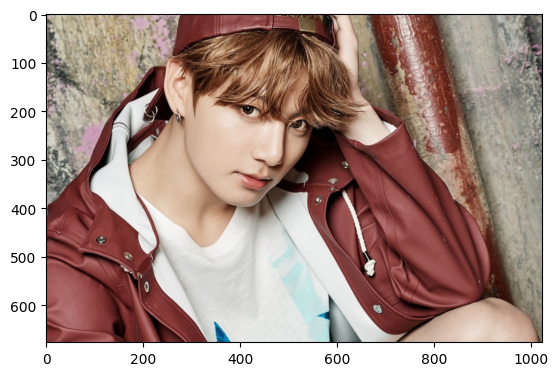

In [5]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

In [4]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_gray

array([[ 68,  63,  61, ..., 116, 124, 135],
       [ 69,  72,  81, ..., 119, 125, 132],
       [ 81,  92, 113, ..., 120, 120, 122],
       ...,
       [ 92,  81,  78, ..., 106, 114, 118],
       [ 89,  80,  77, ...,  95, 110, 116],
       [ 87,  79,  78, ...,  87, 109, 115]], dtype=uint8)

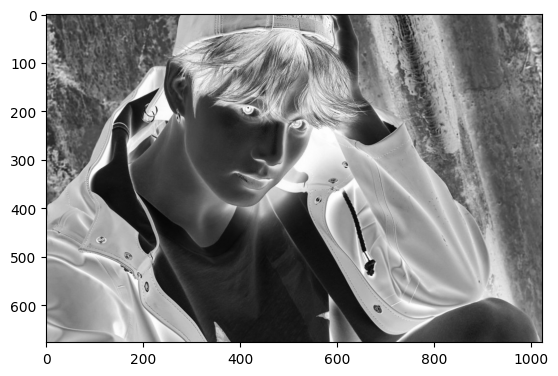

In [9]:
255 - img_gray
plt.imshow(255-img_gray,cmap='gray')

In [8]:
img.shape

(677, 1024, 3)

### Thuật toán Sobel

Sobel là một thuật toán phát hiện biên trong xử lý ảnh, dựa trên việc tính đạo hàm bậc nhất của cường độ sáng trong ảnh. Nó phát hiện các biên bằng cách tìm những thay đổi nhanh chóng về cường độ sáng, thường xảy ra tại các đường biên của đối tượng trong ảnh.

---

### **Nguyên lý hoạt động**

Sobel sử dụng **toán tử tích chập (convolution operator)** với hai ma trận nhân (kernel) để tính gần đúng đạo hàm bậc nhất theo hai hướng: **hướng ngang (x)** và **hướng dọc (y)**.

1. **Kernel Sobel:**
   - Hướng ngang ($G_x$):
     $$
     K_x = 
     \begin{bmatrix}
     -1 & 0 & 1 \\
     -2 & 0 & 2 \\
     -1 & 0 & 1
     \end{bmatrix}
     $$

   - Hướng dọc ($G_y$):
     $$
     K_y = 
     \begin{bmatrix}
     -1 & -2 & -1 \\
      0 &  0 &  0 \\
      1 &  2 &  1
     \end{bmatrix}
     $$

2. **Tính toán đạo hàm x và y:**
   - Đạo hàm theo hướng ngang ($G_x$): Tích chập ảnh đầu vào với $K_x$.
   - Đạo hàm theo hướng dọc ($G_y$): Tích chập ảnh đầu vào với $K_y$.

3. **Độ lớn biên ($G$):**
   Sau khi tính $G_x$ và $G_y$, độ lớn của biên được tính bằng:
   $$
   G = \sqrt{G_x^2 + G_y^2}
   $$
   (hoặc lấy gần đúng $G = |G_x| + |G_y|$ để giảm chi phí tính toán).

4. **Hướng của biên ($\theta$):**
   Hướng của biên được xác định bằng:
   $$
   \theta = \arctan\left(\frac{G_y}{G_x}\right)
   $$

---

### **Các bước thực hiện thuật toán Sobel**

1. **Tiền xử lý:**
   - Chuyển ảnh sang ảnh grayscale (nếu ảnh đầu vào là RGB).
   - Áp dụng bộ lọc Gaussian để giảm nhiễu (không bắt buộc nhưng khuyến khích).

2. **Tích chập với kernel Sobel:**
   - Áp dụng $K_x$ và $K_y$ lên ảnh bằng tích chập để tính $G_x$ và $G_y$.

3. **Tính độ lớn biên:**
   - Kết hợp $G_x$ và $G_y$ để xác định biên.

4. **Ngưỡng hóa (Thresholding):**
   - Loại bỏ các giá trị nhỏ (không phải biên) bằng cách áp dụng ngưỡng.

---

### **Ưu điểm**
- Đơn giản, dễ thực hiện và hiệu quả.
- Có khả năng làm mịn ảnh (nhờ các trọng số trong kernel).
- Phát hiện biên ở cả hai hướng ngang và dọc.

### **Nhược điểm**
- Không phát hiện tốt biên trong ảnh nhiễu (cần kết hợp với lọc trước).
- Khả năng phân biệt biên mờ hoặc biên mạnh có thể hạn chế.
- Không phát hiện tốt các biên cong phức tạp.

---

### **Ứng dụng**
- Phát hiện biên (Edge detection).
- Tiền xử lý trong các bài toán nhận diện đối tượng, phát hiện vật thể.
- Tăng cường chi tiết trong ảnh.


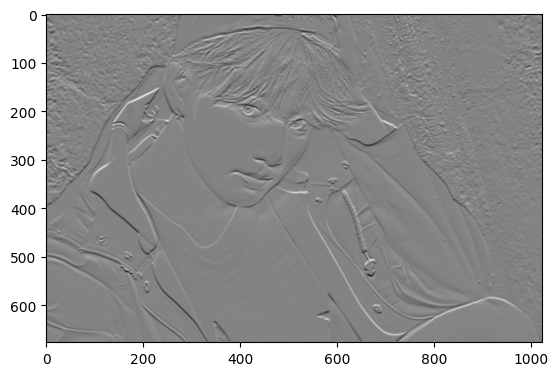

In [9]:
x_sobel = cv2.Sobel(img_gray,cv2.CV_64F,0,1,ksize=7)
plt.imshow(x_sobel, cmap='gray')

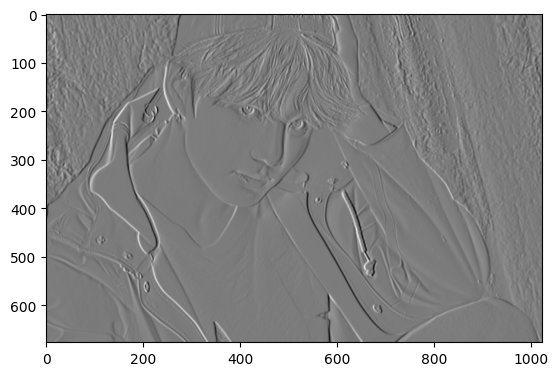

In [16]:
y_sobel = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize = 7)
plt.imshow(y_sobel, cmap='gray')

In [11]:
gradient_magnitude_sobel = np.sqrt(x_sobel**2 + y_sobel**2)

In [12]:
gradient_magnitude_sobel

array([[    0.        ,  9404.        , 16200.        , ...,
         3662.        ,  4514.        ,     0.        ],
       [24212.        , 29626.39448195, 38316.57628234, ...,
         1837.51625843,  5582.60888832,  6652.        ],
       [39474.        , 45855.09884408, 54371.17695986, ...,
         4913.93630402,  9314.3979945 , 11934.        ],
       ...,
       [ 2422.        ,  4804.48644498,  4362.35716099, ...,
        30035.80320218, 17010.31980887,  7132.        ],
       [ 1702.        ,  4310.04640346,  3864.66169283, ...,
        30803.88813121, 19079.93401456,  5190.        ],
       [    0.        ,  3888.        ,  3546.        , ...,
        30294.        , 19368.        ,     0.        ]])

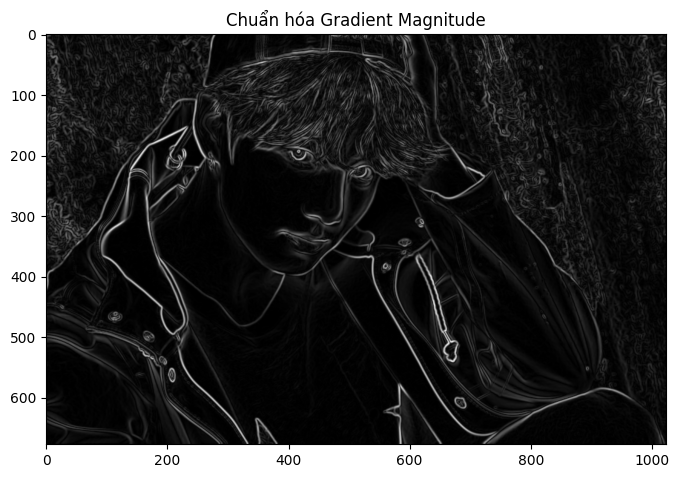

In [13]:
# Chuẩn hóa
min_val = np.min(gradient_magnitude_sobel)
max_val = np.max(gradient_magnitude_sobel)
# Chuẩn hóa về phạm vi [0, 255]
normalized_image = ((gradient_magnitude_sobel - min_val) / (max_val - min_val)) * 255

# Chuyển đổi về kiểu uint8
normalized_image = np.uint8(normalized_image)

# Hiển thị kết quả
plt.figure(figsize=(8, 8))
plt.imshow(normalized_image, cmap='gray')
plt.title('Chuẩn hóa Gradient Magnitude')
plt.show()

In [17]:
normalized_image.max()

255

In [32]:
threshold_value = 25  # Bạn có thể thay đổi giá trị này để điều chỉnh mức độ ngưỡng
_, thresholded_image = cv2.threshold(normalized_image, threshold_value, 255, cv2.THRESH_BINARY)


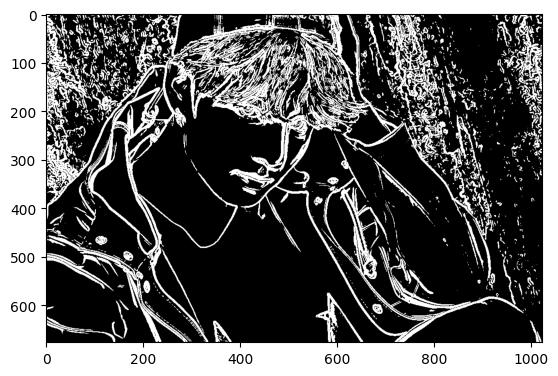

In [33]:
plt.imshow(thresholded_image, cmap='gray')

# Thuật toán Roberts (Roberts Cross Operator)

Bộ lọc Roberts là một trong những toán tử phát hiện biên (edge detection) cơ bản trong xử lý ảnh. Nó được thiết kế để tính toán độ dốc (gradient) của cường độ sáng của ảnh. Bộ lọc này phát hiện biên tại các vị trí có sự thay đổi nhanh chóng về cường độ sáng, thường là đường viền của các đối tượng trong ảnh.

---

### **Nguyên lý hoạt động**

Bộ lọc Roberts sử dụng **tích chập (convolution)** với hai kernel nhỏ, mỗi kernel có kích thước (2*2), để tính gradient theo hai hướng chéo: **dọc-chéo** (diagonal) và **ngang-chéo** (anti-diagonal).

1. **Các kernel Roberts:**
   - Kernel tính gradient theo hướng chéo (\(G_x\)):
     $$
     K_x = 
     \begin{bmatrix}
     1 & 0 \\
     0 & -1
     \end{bmatrix}
     $$

   - Kernel tính gradient theo hướng ngang-chéo (\(G_y\)):
     $$
     K_y = 
     \begin{bmatrix}
     0 & 1 \\
     -1 & 0
     \end{bmatrix}
     $$

2. **Tính toán gradient:**
   - Gradient theo hướng \(x\): \(G_x = I * K_x\)
   - Gradient theo hướng \(y\): \(G_y = I * K_y\)
   - Ở đây, \(I\) là ảnh đầu vào, và \(*\) là phép tích chập.

3. **Độ lớn của biên (\(G\))**:
   Sau khi tính \(G_x\) và \(G_y\), độ lớn của biên được tính bằng:
   $$
   G = \sqrt{G_x^2 + G_y^2}
   $$
   (hoặc gần đúng bằng \(G = |G_x| + |G_y|\)).

---

### **Các bước thực hiện**

1. **Tiền xử lý:**
   - Chuyển ảnh sang grayscale nếu ảnh là RGB.
   - Có thể áp dụng lọc làm mịn (như Gaussian) để giảm nhiễu trước khi dùng bộ lọc.

2. **Tích chập:**
   - Áp dụng kernel \(K_x\) và \(K_y\) lên ảnh bằng phép tích chập để tính gradient.

3. **Tính độ lớn biên:**
   - Kết hợp \(G_x\) và \(G_y\) để tính biên.

4. **Ngưỡng hóa (Thresholding):**
   - Chỉ giữ lại các điểm biên có độ lớn vượt qua một giá trị ngưỡng nhất định.

---

### **Ưu điểm**
- Đơn giản và hiệu quả.
- Kernel nhỏ (2x2), tính toán nhanh hơn so với các phương pháp phức tạp hơn (Sobel hoặc Canny).

### **Nhược điểm**
- Không làm mịn ảnh trước khi phát hiện biên, dẫn đến nhạy cảm với nhiễu.
- Không phát hiện tốt các biên mờ hoặc biên cong phức tạp.
- Khó xử lý ảnh kích thước lớn vì kernel quá nhỏ.

---

### **Ứng dụng**
- Phát hiện biên trong ảnh đơn giản.
- Tiền xử lý trong các bài toán xử lý ảnh cơ bản hoặc thời gian thực.


In [35]:
img2 = cv2.imread('Image/plane.jpg',cv2.IMREAD_GRAYSCALE)

In [36]:
robert_x = np.array([[1, 0], [0, -1]])
robert_y = np.array([[0, 1], [-1, 0]])

In [37]:
# Tính toán sự biến đổi theo cả hai hướng
# -1: Đây là giá trị cho phép chỉ định độ sâu của ảnh đầu ra. Giá trị -1 có nghĩa là giữ nguyên độ sâu của ảnh đầu vào, tức là 
# ảnh đầu ra sẽ có cùng kiểu dữ liệu (số bit) như ảnh đầu vào. 
gradient_x = cv2.filter2D(img2.astype(np.float32), -1, robert_x)
gradient_y = cv2.filter2D(img2.astype(np.float32), -1, robert_y)

In [39]:
# Tính tổng độ thay đổi
gradient_magnitude = np.sqrt(np.square(gradient_x) + np.square(gradient_y))

In [40]:
gradient_magnitude

array([[0.       , 0.       , 1.4142135, ..., 1.4142135, 1.4142135,
        1.4142135],
       [0.       , 0.       , 1.4142135, ..., 1.4142135, 1.4142135,
        1.4142135],
       [0.       , 0.       , 1.4142135, ..., 1.4142135, 1.4142135,
        1.4142135],
       ...,
       [1.4142135, 1.4142135, 2.       , ..., 0.       , 0.       ,
        0.       ],
       [1.       , 1.       , 2.       , ..., 8.485281 , 8.485281 ,
        7.81025  ],
       [1.4142135, 1.4142135, 1.4142135, ..., 0.       , 0.       ,
        1.4142135]], dtype=float32)

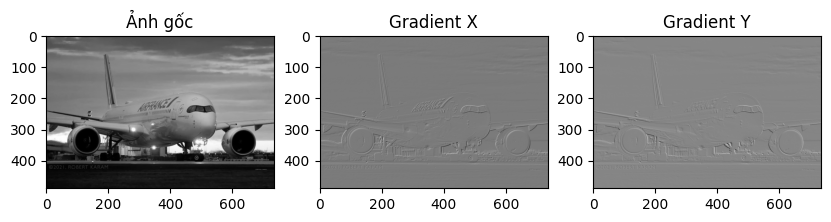

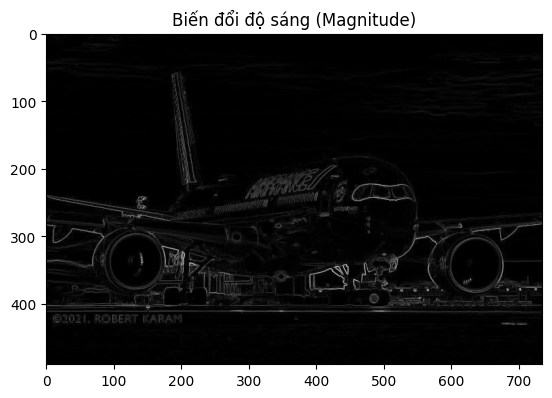

In [41]:
plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1), plt.imshow(img2, cmap='gray'), plt.title('Ảnh gốc')
plt.subplot(1, 3, 2), plt.imshow(gradient_x, cmap='gray'), plt.title('Gradient X')
plt.subplot(1, 3, 3), plt.imshow(gradient_y, cmap='gray'), plt.title('Gradient Y')
plt.show()

plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Biến đổi độ sáng (Magnitude)')
plt.show()

# Bộ lọc Prewitt

Bộ lọc Prewitt là một loại bộ lọc đạo hàm được sử dụng trong xử lý ảnh, nhằm phát hiện biên (edges) trong hình ảnh. Bộ lọc này là một dạng của bộ lọc gradient, có nhiệm vụ làm nổi bật sự thay đổi cường độ sáng của pixel trong ảnh, giúp phát hiện các biên hoặc sự thay đổi trong hình ảnh.

Bộ lọc Prewitt sử dụng hai ma trận (kernel) để tính toán gradient theo phương ngang (Gx) và phương dọc (Gy). Các ma trận này được áp dụng lên mỗi pixel trong ảnh, với mục đích tính toán sự thay đổi cường độ sáng theo hướng ngang và dọc.

### Các ma trận Prewitt:
- **Ma trận Prewitt theo phương ngang (Gx):**

  $$
  G_x = \begin{bmatrix} 
  -1 & 0 & 1 \\
  -1 & 0 & 1 \\
  -1 & 0 & 1
  \end{bmatrix}
  $$

- **Ma trận Prewitt theo phương dọc (Gy):**

  $$
  G_y = \begin{bmatrix} 
  -1 & -1 & -1 \\
  0 & 0 & 0 \\
  1 & 1 & 1
  \end{bmatrix}
  $$

In [68]:
img3 = cv2.imread('Image/plane.jpg',cv2.IMREAD_GRAYSCALE)

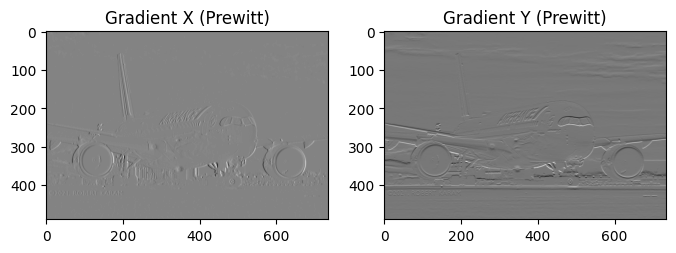

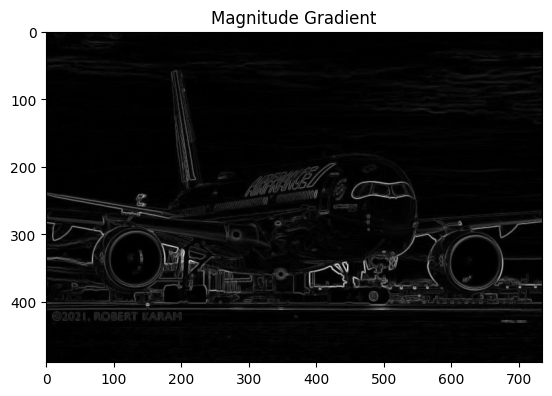

In [110]:
kernel_x_pre = np.array([[-1, 0, 1],
                     [-1, 0, 1],
                     [-1, 0, 1]])

# Bộ lọc Prewitt theo hướng Y (dọc)
kernel_y_pre = np.array([[-1, -1, -1],
                     [0,  0,  0],
                     [1,  1,  1]])

# Áp dụng bộ lọc Prewitt với filter2D
gradient_x_pre = cv2.filter2D(img3.astype(np.float32), -1, kernel_x_pre)
gradient_y_pre = cv2.filter2D(img3.astype(np.float32), -1, kernel_y_pre)

# # Tính magnitude của gradient
gradient_magnitude_pre = np.sqrt(gradient_x_pre**2 + gradient_y_pre**2)
gradient_magnitude_pre = np.array(gradient_magnitude_pre, dtype=np.float32)

# # Chuẩn hóa về phạm vi [0, 255]
gradient_magnitude_pre_normal = cv2.convertScaleAbs(gradient_magnitude_pre)

# # Hiển thị kết quả
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1), plt.imshow(gradient_x_pre, cmap='gray'), plt.title('Gradient X (Prewitt)')
plt.subplot(1, 2, 2), plt.imshow(gradient_y_pre, cmap='gray'), plt.title('Gradient Y (Prewitt)')

plt.show()
plt.imshow(gradient_magnitude_pre, cmap='gray'), plt.title('Magnitude Gradient')
plt.show()

In [88]:
gradient_magnitude_pre

array([[0.       , 3.       , 6.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 3.       , 6.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 3.       , 5.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [1.       , 1.       , 0.       , ..., 8.25     , 5.7460938,
        5.7460938],
       [0.       , 0.       , 0.       , ..., 8.25     , 5.7460938,
        5.7460938],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ]], dtype=float32)

# Đạo hàm bậc 2
# laplacian

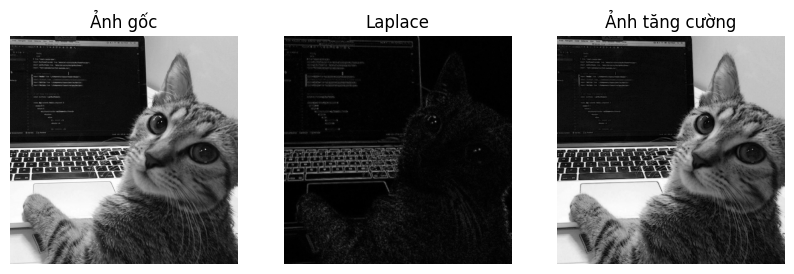

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh
image = cv2.imread('Image/d7b2e52d246dffe794a6a1c750a05593.jpg', cv2.IMREAD_GRAYSCALE)  # Đọc ảnh xám

# Làm mờ ảnh để giảm nhiễu
blurred = cv2.GaussianBlur(image, (3, 3), 0)

# Áp dụng toán tử Laplacian
laplacian = cv2.Laplacian(blurred, cv2.CV_64F)

# Chuyển về dạng tuyệt đối để hiển thị
laplacian = np.uint8(np.abs(laplacian))

# Hiển thị kết quả
alpha = 1.0  # Hệ số điều chỉnh
enhanced = cv2.subtract(image, np.uint8(alpha * laplacian))

# Hiển thị kết quả
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(laplacian, cmap='gray')
plt.title("Laplace")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(enhanced, cmap='gray')
plt.title("Ảnh tăng cường")
plt.axis("off")

plt.show()


In [ ]:
enhanced = cv2.subtract(image, alpha * laplacian)